In [2]:
import numpy as np
from PIL import Image
import cv2
import cv2.aruco
import matplotlib.pyplot as plt

In [4]:
import importlib

# Update methods

In [20]:
import image_builder
importlib.reload(image_builder)

<module 'image_builder' from '/Users/anthonyliu/Projects/receipt-printer-exquisite-corpse/src/image_builder.py'>

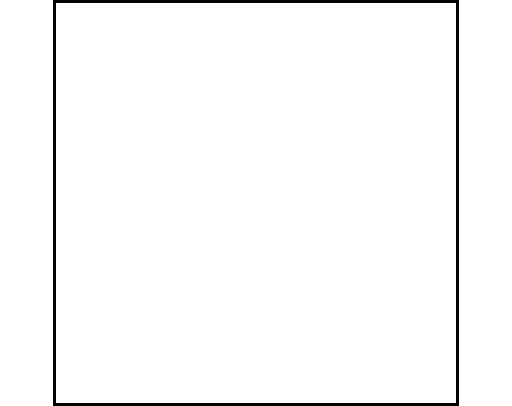

In [21]:
Image.fromarray(image_builder.build_drawing_area())

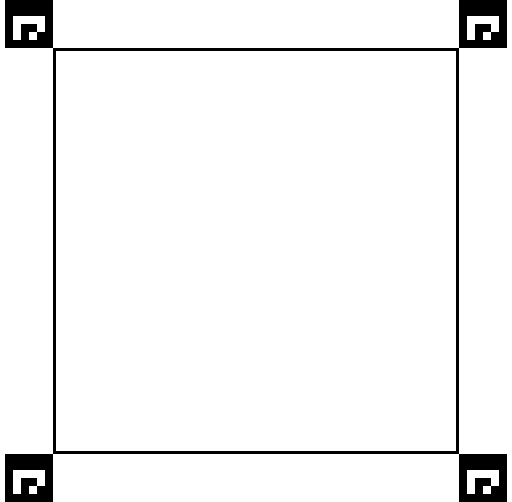

In [25]:
w_markers = image_builder.build_drawing_area_with_aruco_markers(
    (1, 1, 1, 1)
)
Image.fromarray(w_markers)

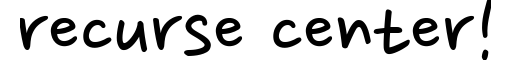

In [31]:
title = image_builder.build_title(
    "recurse center!",
    "../data/NanumPenScript-Regular.ttf",
    90,
)
Image.fromarray(title)

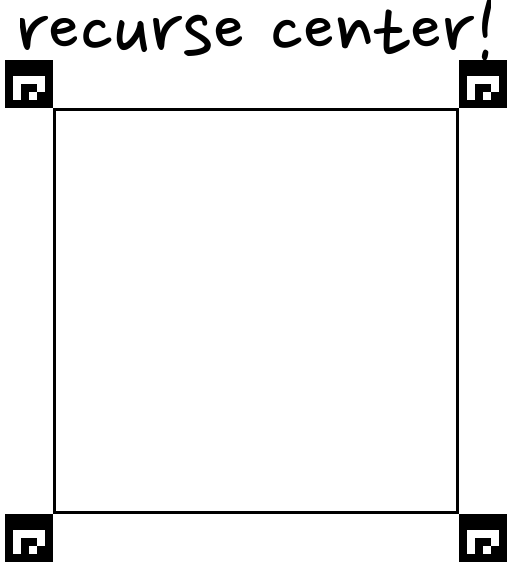

In [32]:
Image.fromarray(np.vstack([
    title,
    w_markers
]))

# OLD

# Drawing area

In [11]:
def show_im(array):
    plt.figure()
    plt.imshow(blank_image, cmap='gray', vmin=0, vmax=255)
    plt.legend()
    plt.show()

In [45]:
blank_image = np.ones((512, 512), dtype=np.uint8) * 255

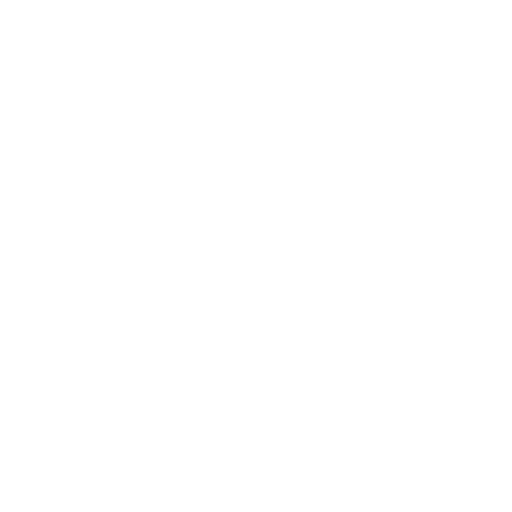

In [46]:
Image.fromarray(blank_image, mode='L')

In [67]:
def get_drawing_area(bg_color: int = 220):
    with_grid = np.ones((512, 512), dtype=np.uint8) * bg_color
    
    FULL_WIDTH_SIZE = 512
    BORDER_WIDTH = 3
    DRAWING_AREA_SIZE = 400
    
    MARGIN_X = int((FULL_WIDTH_SIZE - DRAWING_AREA_SIZE - 2 * BORDER_WIDTH)/ 2)
    
    print(f"MARGIN is {MARGIN_X}")
    
    if not isinstance(MARGIN_X, int):
        raise Exception("MARGIN_X NEEDS TO BE INT")
    
    OFFSET_Y = MARGIN_X
    
    TOP_RIGHT_X = MARGIN_X
    TOP_RIGHT_Y = OFFSET_Y
    BOTTOM_LEFT_X = FULL_WIDTH_SIZE - MARGIN_X
    BOTTOM_LEFT_Y = FULL_WIDTH_SIZE - OFFSET_Y
    
    for y in range(TOP_RIGHT_Y, BOTTOM_LEFT_Y + 1):
        if (y - TOP_RIGHT_Y) <= 3:
            with_grid[y, TOP_RIGHT_X:BOTTOM_LEFT_X] = 0
        elif (BOTTOM_LEFT_Y - y) <= 3:
            with_grid[y, TOP_RIGHT_X:BOTTOM_LEFT_X] = 0
        else:
            with_grid[y, TOP_RIGHT_X:(TOP_RIGHT_X + 3)] = 0
            with_grid[y, (BOTTOM_LEFT_X - 3):BOTTOM_LEFT_X] = 0

    return with_grid

## Add aruco

In [64]:
def get_marker(i: int, size: int=48):
    if i < 0 or i > 999:
        raise Exception("Out of bounds i; choose between 0-999")
        
    return cv2.aruco.generateImageMarker(
        cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_1000),
        i,
        size,
    )

In [248]:
drawing_grid = get_drawing_area()

MARGIN is 53


In [249]:
MARGIN_X = 53
OFFSET_Y = MARGIN_X
FULL_WIDTH = 512
BORDER_WIDTH = 0 # 3
ARUCO_WIDTH = 48

tl_00 = (
    MARGIN_X + BORDER_WIDTH - ARUCO_WIDTH,
    OFFSET_Y + BORDER_WIDTH - ARUCO_WIDTH,
)

tl_01 = (
    FULL_WIDTH - BORDER_WIDTH - MARGIN_X,
    tl_00[1],
)

tl_10 = (
    tl_00[0],
    FULL_WIDTH - OFFSET_Y - BORDER_WIDTH + 1,
)

tl_11 = (
    tl_01[0],
    tl_10[1],
)   

In [250]:
def add_marker(img_to_modify, marker_array, x, y):
    w, h = marker_array.shape
    img_to_modify[y:(y+h), x:(x + w)] = marker_array
    return img_to_modify

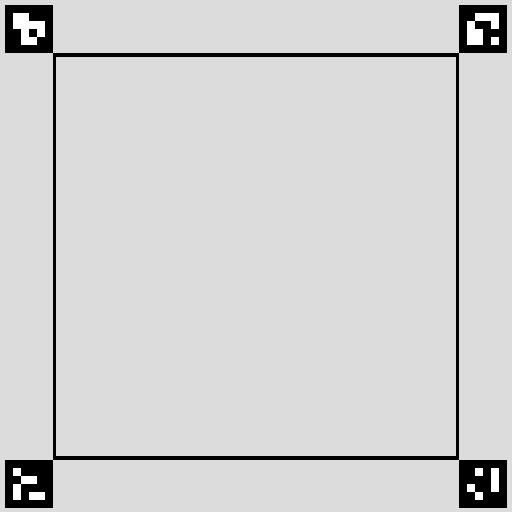

In [251]:
sz = ARUCO_WIDTH
add_marker(drawing_grid, get_marker(9, size=sz), tl_00[0], tl_00[1])
add_marker(drawing_grid, get_marker(5, size=sz), tl_01[0], tl_01[1])
add_marker(drawing_grid, get_marker(20, size=sz), tl_10[0], tl_10[1])
add_marker(drawing_grid, get_marker(50, size=sz), tl_11[0], tl_11[1])

test_img = Image.fromarray(drawing_grid, mode="L")

test_img

## Make sure we can round trip this

In [252]:
frame = cv2.imread('image04.jpeg')
img_in = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

In [253]:
img_in = np.array(test_img)

aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_1000)
parameters = cv2.aruco.DetectorParameters()
corners, ids, rejectedImgPoints = (
    cv2.aruco.ArucoDetector(aruco_dict, parameters)
    .detectMarkers(img_in)
)
frame_markers = cv2.aruco.drawDetectedMarkers(img_in.copy(), corners, ids)

In [254]:
ids

array([[50],
       [20],
       [ 5],
       [ 9]], dtype=int32)

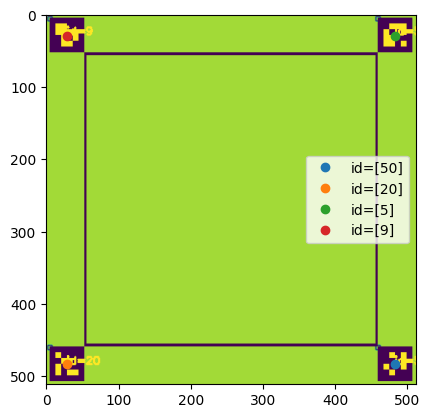

In [255]:
plt.figure()
plt.imshow(frame_markers)
for i in range(len(ids)):
    c = corners[i][0]
    plt.plot([c[:, 0].mean()], [c[:, 1].mean()], "o", label = "id={0}".format(ids[i]))
plt.legend()
plt.show()

In [256]:
ids

array([[50],
       [20],
       [ 5],
       [ 9]], dtype=int32)

In [257]:
frame_boundaries = np.array([
    corners[0][:, 0],
    corners[1][:, 1],
    corners[3][:, 2],
    corners[2][:, 3],
]).astype(int)

In [258]:
tgt_dims = np.array([
    [DRAWING_AREA_SIZE, DRAWING_AREA_SIZE], 
    [DRAWING_AREA_SIZE,0], 
    [0,0], 
    [0,DRAWING_AREA_SIZE],
])

# Titles

In [259]:
ttf_font = './NanumPenScript-Regular.ttf'

In [260]:
ttf_font

'./NanumPenScript-Regular.ttf'

In [261]:
blank_image = np.ones((100, 512), dtype=np.uint8) * 225
img = Image.fromarray(blank_image)

# Importing the PIL library
from PIL import Image
from PIL import ImageDraw
from PIL import ImageFont

# Call draw Method to add 2D graphics in an image
I1 = ImageDraw.Draw(img)

# Custom font style and font size
myFont = ImageFont.truetype(ttf_font, 80)

# Add Text to an image
I1.text((45, 15), "recurse center!", font=myFont, fill =(0, ))

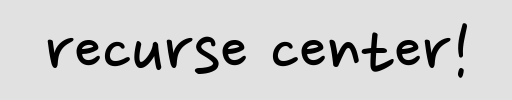

In [262]:
img

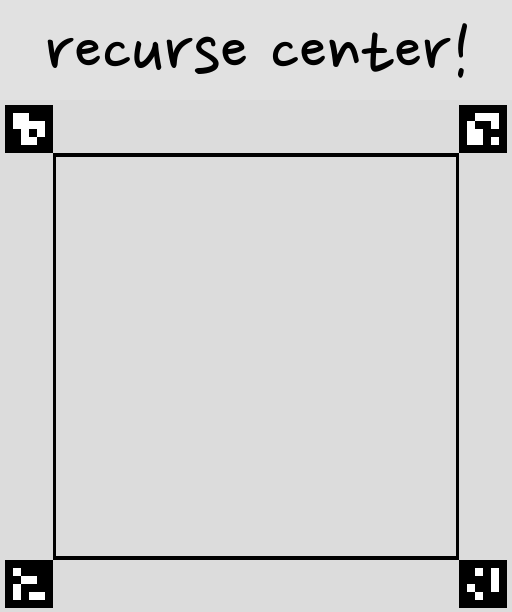

In [264]:
_a = np.vstack([
    np.array(img),
    np.array(test_img)[:, :],
])

Image.fromarray(_a, mode='L')

In [235]:
(z > 0).cumsum()

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9,
       10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26,
       27, 28, 29, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30,
       30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30])